In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import gc
import glob
from tqdm import tqdm
warnings.filterwarnings('ignore')

# PyTorch and GPU Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler

# Sklearn for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("GPU-ACCELERATED FLIGHT DELAY PREDICTION PIPELINE")
print("="*80)

GPU-ACCELERATED FLIGHT DELAY PREDICTION PIPELINE


In [2]:
print("\n" + "="*80)
print("GPU CONFIGURATION")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Using device: {device}")

if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
    print("✓ GPU optimizations enabled!")

# Configuration
CONFIG = {
    'batch_size': 16384,      # Large batch for GPU
    'num_workers': 4,          # Reduced to save RAM
    'pin_memory': True,
    'learning_rate': 0.001,
    'epochs': 30,
    'hidden_dims': [1024, 512, 256, 128],
    'dropout': 0.3,
    'weight_decay': 1e-5,
    'sample_size': 5000000,    # Process 5M samples at a time
    'chunk_size': 50000        # Read 50k rows per chunk
}

print(f"\n✓ Batch Size: {CONFIG['batch_size']} (GPU optimized)")
print(f"✓ Chunk Size: {CONFIG['chunk_size']} (memory efficient)")


GPU CONFIGURATION

✓ Using device: cuda
✓ GPU: NVIDIA GeForce GTX 1650
✓ Total GPU Memory: 4.00 GB
✓ GPU optimizations enabled!

✓ Batch Size: 16384 (GPU optimized)
✓ Chunk Size: 50000 (memory efficient)


In [3]:
print("\n" + "="*80)
print("STEP 1: MEMORY-EFFICIENT DATA LOADING")
print("="*80)

def process_flight_chunks_streaming(file_pattern, sample_size=None):
    """
    Stream and process flight data without loading everything into memory
    """
    files = sorted(glob.glob(file_pattern))
    print(f"\nFound {len(files)} flight files")
    
    # First pass: collect statistics for preprocessing
    print("\n📊 Pass 1: Collecting statistics...")
    total_rows = 0
    delay_counts = {0: 0, 1: 0}
    
    for file in tqdm(files, desc="Scanning files"):
        try:
            for chunk in pd.read_csv(file, chunksize=CONFIG['chunk_size'], low_memory=False):
                total_rows += len(chunk)
                if 'ARR_DELAY' in chunk.columns:
                    delayed = (chunk['ARR_DELAY'] >= 15).fillna(0).astype(int)
                    delay_counts[0] += (delayed == 0).sum()
                    delay_counts[1] += (delayed == 1).sum()
                
                if sample_size and total_rows >= sample_size:
                    break
        except Exception as e:
            print(f"⚠ Warning: {file} - {str(e)}")
            continue
        
        if sample_size and total_rows >= sample_size:
            break
    
    print(f"\n✓ Total rows found: {total_rows:,}")
    print(f"✓ Delay distribution: On-time={delay_counts[0]:,}, Delayed={delay_counts[1]:,}")
    
    # Second pass: collect samples
    print(f"\n📥 Pass 2: Loading data (max {sample_size:,} samples)...")
    
    selected_data = []
    rows_collected = 0
    
    # Required columns
    required_cols = [
        'YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
        'OP_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME',
        'DEP_DELAY', 'ARR_DELAY', 'DISTANCE'
    ]
    
    for file in tqdm(files, desc="Loading data"):
        try:
            for chunk in pd.read_csv(file, chunksize=CONFIG['chunk_size'], low_memory=False):
                # Select only required columns that exist
                available_cols = [col for col in required_cols if col in chunk.columns]
                chunk = chunk[available_cols].copy()
                
                # Create target variable
                if 'ARR_DELAY' in chunk.columns:
                    chunk['is_delayed'] = (chunk['ARR_DELAY'] >= 15).fillna(0).astype(int)
                elif 'DEP_DELAY' in chunk.columns:
                    chunk['is_delayed'] = (chunk['DEP_DELAY'] >= 15).fillna(0).astype(int)
                else:
                    continue
                
                # Remove rows with missing critical data
                chunk = chunk.dropna(subset=['ORIGIN', 'DEST', 'is_delayed'])
                
                selected_data.append(chunk)
                rows_collected += len(chunk)
                
                if sample_size and rows_collected >= sample_size:
                    break
        except Exception as e:
            print(f"⚠ Warning: {file} - {str(e)}")
            continue
        
        if sample_size and rows_collected >= sample_size:
            break
        
        # Clear memory periodically
        if len(selected_data) > 20:
            selected_data = [pd.concat(selected_data, ignore_index=True)]
            gc.collect()
    
    print(f"\n✓ Combining {len(selected_data)} chunks...")
    flight_df = pd.concat(selected_data, ignore_index=True)
    
    if sample_size:
        flight_df = flight_df.head(sample_size)
    
    del selected_data
    gc.collect()
    
    print(f"✓ Loaded: {len(flight_df):,} records")
    print(f"✓ Memory: {flight_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return flight_df

def process_weather_chunks_streaming(file_pattern, sample_size=None):
    """
    Stream and process weather data without loading everything into memory
    """
    files = sorted(glob.glob(file_pattern))
    print(f"\nFound {len(files)} weather files")
    
    weather_list = []
    rows_collected = 0
    
    required_cols = ['STATION', 'DATE', 'TMP', 'DEW', 'SLP', 'VIS', 'WND']
    
    print("\n📥 Loading weather data...")
    for file in tqdm(files, desc="Loading weather"):
        try:
            for chunk in pd.read_csv(file, chunksize=CONFIG['chunk_size'], low_memory=False):
                available_cols = [col for col in required_cols if col in chunk.columns]
                if not available_cols:
                    continue
                
                chunk = chunk[available_cols].copy()
                weather_list.append(chunk)
                rows_collected += len(chunk)
                
                if sample_size and rows_collected >= sample_size * 10:  # More weather data
                    break
        except Exception as e:
            print(f"⚠ Warning: {file} - {str(e)}")
            continue
        
        if sample_size and rows_collected >= sample_size * 10:
            break
        
        # Clear memory periodically
        if len(weather_list) > 20:
            weather_list = [pd.concat(weather_list, ignore_index=True)]
            gc.collect()
    
    print(f"\n✓ Combining weather chunks...")
    weather_df = pd.concat(weather_list, ignore_index=True)
    
    del weather_list
    gc.collect()
    
    print(f"✓ Loaded: {len(weather_df):,} weather records")
    print(f"✓ Memory: {weather_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return weather_df

# Load data with memory constraints
print("\n" + "-"*80)
print("Loading Flight Data (memory-efficient)...")
print("-"*80)

flight_data = process_flight_chunks_streaming(
    'D:/Dataset/Original dataset/*.csv',
    sample_size=CONFIG['sample_size']
)

print("\n" + "-"*80)
print("Loading Weather Data (memory-efficient)...")
print("-"*80)

weather_data = process_weather_chunks_streaming(
    'D:/Dataset/Weather Data/*.csv',
    sample_size=CONFIG['sample_size']
)



STEP 1: MEMORY-EFFICIENT DATA LOADING

--------------------------------------------------------------------------------
Loading Flight Data (memory-efficient)...
--------------------------------------------------------------------------------

Found 157 flight files

📊 Pass 1: Collecting statistics...


Scanning files:   6%|▌         | 9/157 [00:42<11:43,  4.75s/it]



✓ Total rows found: 5,036,082
✓ Delay distribution: On-time=3,731,938, Delayed=763,360

📥 Pass 2: Loading data (max 5,000,000 samples)...


Loading data:   6%|▋         | 10/157 [00:40<09:56,  4.06s/it]



✓ Combining 10 chunks...
✓ Loaded: 5,000,000 records
✓ Memory: 1416.23 MB

--------------------------------------------------------------------------------
Loading Weather Data (memory-efficient)...
--------------------------------------------------------------------------------

Found 14 weather files

📥 Loading weather data...


Loading weather: 100%|██████████| 14/14 [00:01<00:00, 13.48it/s]



✓ Combining weather chunks...
✓ Loaded: 107,002 weather records
✓ Memory: 37.55 MB


In [4]:
print("\n" + "="*80)
print("STEP 2: EFFICIENT PREPROCESSING")
print("="*80)

# Convert dates
print("\n✓ Processing dates...")
flight_data['FL_DATE'] = pd.to_datetime(flight_data['FL_DATE'], errors='coerce')
weather_data['DATE'] = pd.to_datetime(weather_data['DATE'], errors='coerce')

# Process weather fields
print("✓ Processing weather data...")

def safe_extract_number(val):
    """Safely extract number from string"""
    if pd.isna(val):
        return np.nan
    try:
        # Extract first number from string
        import re
        numbers = re.findall(r'[-+]?\d*\.?\d+', str(val))
        return float(numbers[0]) if numbers else np.nan
    except:
        return np.nan

# Process weather columns efficiently
if 'TMP' in weather_data.columns:
    weather_data['temperature'] = weather_data['TMP'].apply(safe_extract_number)
if 'DEW' in weather_data.columns:
    weather_data['dew_point'] = weather_data['DEW'].apply(safe_extract_number)
if 'SLP' in weather_data.columns:
    weather_data['sea_level_pressure'] = weather_data['SLP'].apply(safe_extract_number)
if 'VIS' in weather_data.columns:
    weather_data['visibility'] = weather_data['VIS'].apply(safe_extract_number)
if 'WND' in weather_data.columns:
    weather_data['wind_speed'] = weather_data['WND'].apply(safe_extract_number)

weather_data['precipitation'] = 0  # Default

# Aggregate weather by date and station
print("✓ Aggregating weather data...")
weather_data['DATE'] = weather_data['DATE'].dt.date
weather_data['DATE'] = pd.to_datetime(weather_data['DATE'])

agg_cols = {}
for col in ['temperature', 'dew_point', 'sea_level_pressure', 'visibility', 'wind_speed', 'precipitation']:
    if col in weather_data.columns:
        agg_cols[col] = 'mean'

weather_daily = weather_data.groupby(['STATION', 'DATE']).agg(agg_cols).reset_index()

print(f"✓ Weather aggregated: {len(weather_daily):,} records")

# Clear memory
del weather_data
gc.collect()


STEP 2: EFFICIENT PREPROCESSING

✓ Processing dates...
✓ Processing weather data...
✓ Aggregating weather data...
✓ Weather aggregated: 4,813 records


22

In [5]:
print("\n" + "="*80)
print("STEP 3: MERGING FLIGHT AND WEATHER DATA")
print("="*80)

# Create simplified airport-station mapping
print("\n✓ Creating airport-station mapping...")

unique_airports = pd.concat([flight_data['ORIGIN'], flight_data['DEST']]).unique()
unique_stations = weather_daily['STATION'].unique()

# Create mapping based on common patterns
airport_station_map = {}
for airport in unique_airports:
    if pd.notna(airport):
        airport_str = str(airport).upper()
        # Find matching station
        for station in unique_stations:
            if airport_str in str(station).upper():
                airport_station_map[airport] = station
                break
        # Default to first station if no match
        if airport not in airport_station_map:
            airport_station_map[airport] = unique_stations[0] if len(unique_stations) > 0 else 'UNKNOWN'

print(f"✓ Mapped {len(airport_station_map)} airports")

# Add mappings
flight_data['ORIGIN_STATION'] = flight_data['ORIGIN'].map(airport_station_map)
flight_data['DEST_STATION'] = flight_data['DEST'].map(airport_station_map)

# Merge with weather (left join to keep all flights)
print("\n✓ Merging with origin weather...")
merged_data = flight_data.merge(
    weather_daily,
    left_on=['ORIGIN_STATION', 'FL_DATE'],
    right_on=['STATION', 'DATE'],
    how='left',
    suffixes=('', '_origin')
)

# Rename origin columns
for col in agg_cols.keys():
    if col in merged_data.columns:
        merged_data.rename(columns={col: f'origin_{col}'}, inplace=True)

print("✓ Merging with destination weather...")
merged_data = merged_data.merge(
    weather_daily,
    left_on=['DEST_STATION', 'FL_DATE'],
    right_on=['STATION', 'DATE'],
    how='left',
    suffixes=('', '_dest')
)

# Rename dest columns
for col in agg_cols.keys():
    if col in merged_data.columns:
        merged_data.rename(columns={col: f'dest_{col}'}, inplace=True)

print(f"\n✓ Merged data: {len(merged_data):,} records")

# Clear memory
del flight_data, weather_daily
gc.collect()


STEP 3: MERGING FLIGHT AND WEATHER DATA

✓ Creating airport-station mapping...
✓ Mapped 313 airports

✓ Merging with origin weather...
✓ Merging with destination weather...

✓ Merged data: 5,000,000 records


0

In [6]:
(merged_data.select_dtypes(include=['number']) < 0).sum()


YEAR                               0
MONTH                              0
DAY_OF_MONTH                       0
DAY_OF_WEEK                        0
CRS_DEP_TIME                       0
DEP_DELAY                    2853236
ARR_DELAY                    3056822
DISTANCE                           0
is_delayed                         0
ORIGIN_STATION                     0
DEST_STATION                       0
STATION                            0
origin_temperature           2072058
origin_dew_point             3191586
origin_sea_level_pressure          0
origin_visibility                  0
origin_wind_speed                  0
origin_precipitation               0
STATION_dest                       0
dest_temperature             2072058
dest_dew_point               3191586
dest_sea_level_pressure            0
dest_visibility                    0
dest_wind_speed                    0
dest_precipitation                 0
dtype: int64

In [7]:
# Make a copy to avoid overwriting raw data
cleaned_data = merged_data.copy()

# 1. Flight delays — negative = early arrival/departure, not an error
# So only remove extreme invalid ones (< -60 minutes or unrealistic)
cleaned_data = cleaned_data[~((cleaned_data['ARR_DELAY'] < -60) | (cleaned_data['DEP_DELAY'] < -60))]

# 2. Distance — must be positive
cleaned_data = cleaned_data[cleaned_data['DISTANCE'] > 0]

# 3. Weather values — negative temperatures are valid, but not for pressure or visibility
numeric_cols = ['origin_sea_level_pressure', 'dest_sea_level_pressure', 'origin_visibility', 'dest_visibility']
for col in numeric_cols:
    cleaned_data = cleaned_data[cleaned_data[col] >= 0]

# 4. Optional: Drop any remaining negative values globally
cleaned_data = cleaned_data[(cleaned_data.select_dtypes(include=['number']) >= 0).all(axis=1)]


In [8]:
(cleaned_data.select_dtypes(include=['number']) < 0).sum()


YEAR                         0
MONTH                        0
DAY_OF_MONTH                 0
DAY_OF_WEEK                  0
CRS_DEP_TIME                 0
DEP_DELAY                    0
ARR_DELAY                    0
DISTANCE                     0
is_delayed                   0
ORIGIN_STATION               0
DEST_STATION                 0
STATION                      0
origin_temperature           0
origin_dew_point             0
origin_sea_level_pressure    0
origin_visibility            0
origin_wind_speed            0
origin_precipitation         0
STATION_dest                 0
dest_temperature             0
dest_dew_point               0
dest_sea_level_pressure      0
dest_visibility              0
dest_wind_speed              0
dest_precipitation           0
dtype: int64

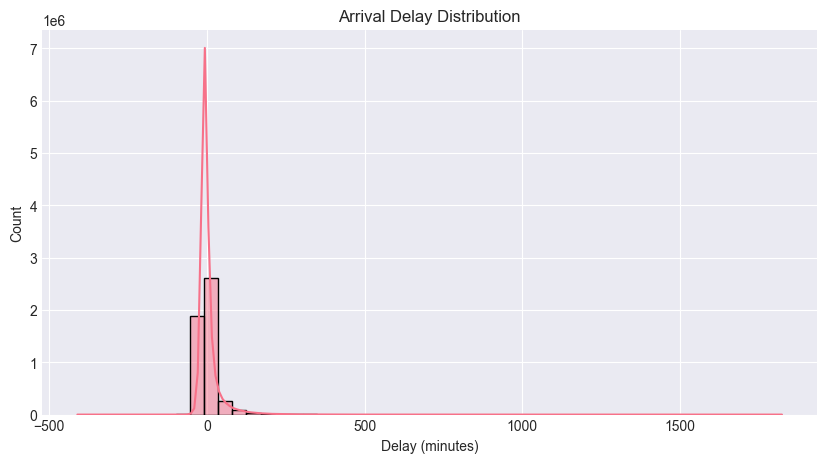

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(merged_data['ARR_DELAY'].dropna(), bins=50, kde=True)
plt.title("Arrival Delay Distribution")
plt.xlabel("Delay (minutes)")
plt.show()


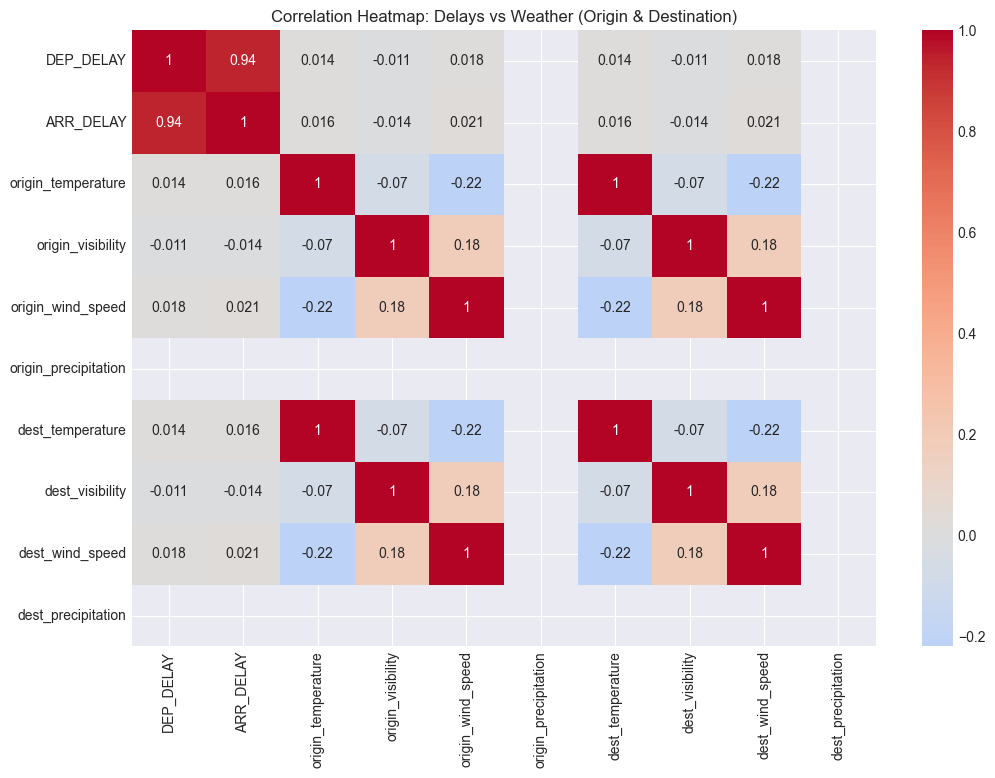

In [10]:
plt.figure(figsize=(12, 8))
corr_cols = [
    'DEP_DELAY', 'ARR_DELAY',
    'origin_temperature', 'origin_visibility', 'origin_wind_speed', 'origin_precipitation',
    'dest_temperature', 'dest_visibility', 'dest_wind_speed', 'dest_precipitation'
]

sns.heatmap(merged_data[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Delays vs Weather (Origin & Destination)")
plt.show()

In [ ]:
merged_data['temp_diff'] = merged_data['origin_temperature'] - merged_data['dest_temperature']

plt.figure(figsize=(10,6))
sns.scatterplot(data=merged_data, x='temp_diff', y='ARR_DELAY', alpha=0.5)
sns.regplot(data=merged_data, x='temp_diff', y='ARR_DELAY', scatter=False, color='red')
plt.title("Temperature Difference vs Arrival Delay")
plt.xlabel("Origin - Destination Temperature Difference (°C)")
plt.ylabel("Arrival Delay (min)")
plt.show()


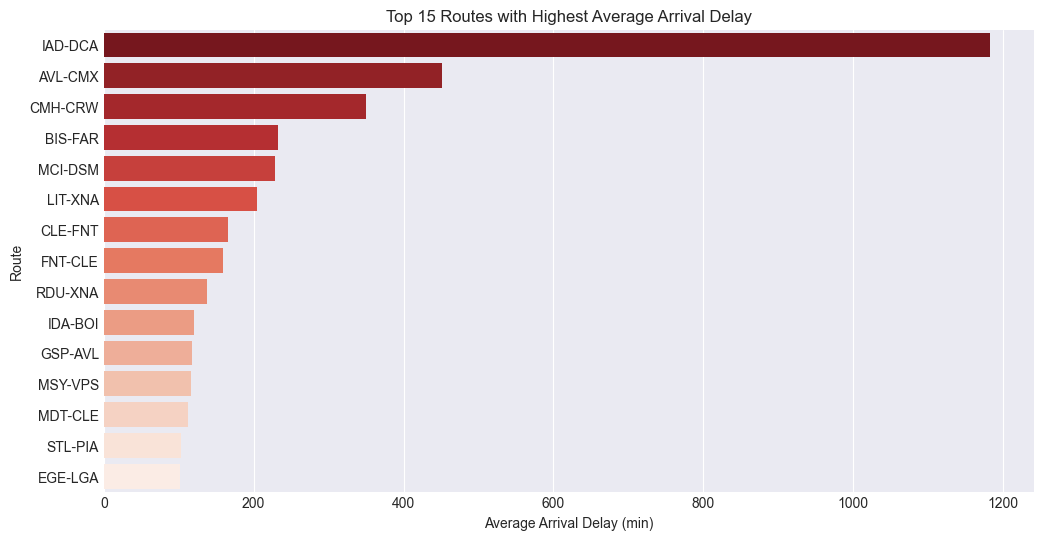

In [ ]:
top_routes = (merged_data.groupby(['ORIGIN','DEST'])['ARR_DELAY']
              .mean().sort_values(ascending=False).head(15).reset_index())

plt.figure(figsize=(12,6))
sns.barplot(data=top_routes, x='ARR_DELAY', y=top_routes['ORIGIN'] + '-' + top_routes['DEST'], palette='Reds_r')
plt.title("Top 15 Routes with Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (min)")
plt.ylabel("Route")
plt.show()


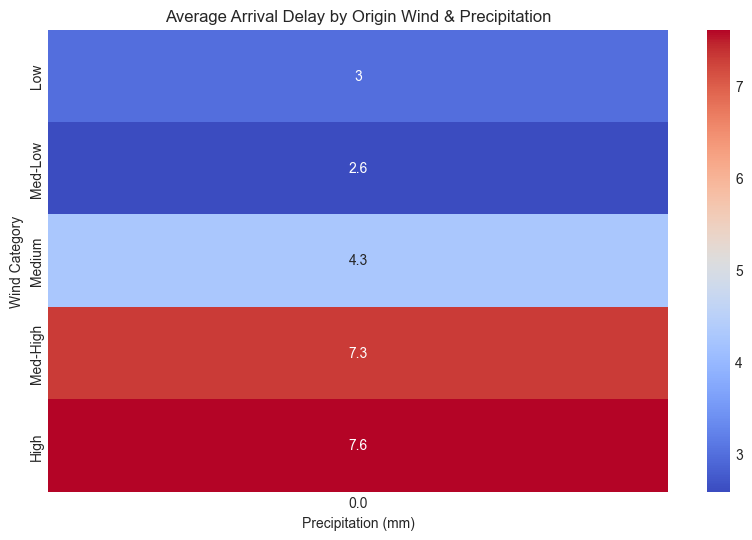

In [ ]:
merged_data['origin_wind_bin'] = pd.cut(merged_data['origin_wind_speed'], bins=5, labels=['Low','Med-Low','Medium','Med-High','High'])
pivot = merged_data.pivot_table(values='ARR_DELAY', index='origin_wind_bin', columns='origin_precipitation', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Average Arrival Delay by Origin Wind & Precipitation")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Wind Category")
plt.show()



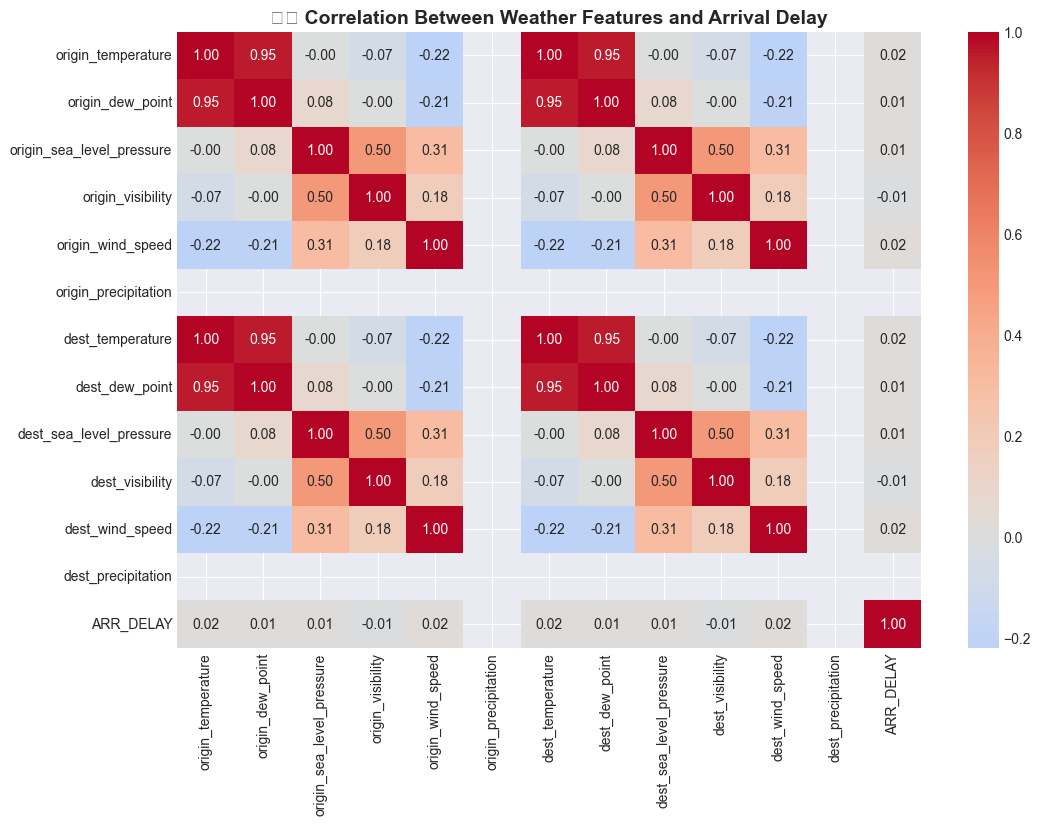

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

weather_cols = [
    'origin_temperature', 'origin_dew_point', 'origin_sea_level_pressure',
    'origin_visibility', 'origin_wind_speed', 'origin_precipitation',
    'dest_temperature', 'dest_dew_point', 'dest_sea_level_pressure',
    'dest_visibility', 'dest_wind_speed', 'dest_precipitation'
]

corr = merged_data[weather_cols + ['ARR_DELAY']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', center=0)
plt.title('🌦️ Correlation Between Weather Features and Arrival Delay', fontsize=14, fontweight='bold')
plt.show()


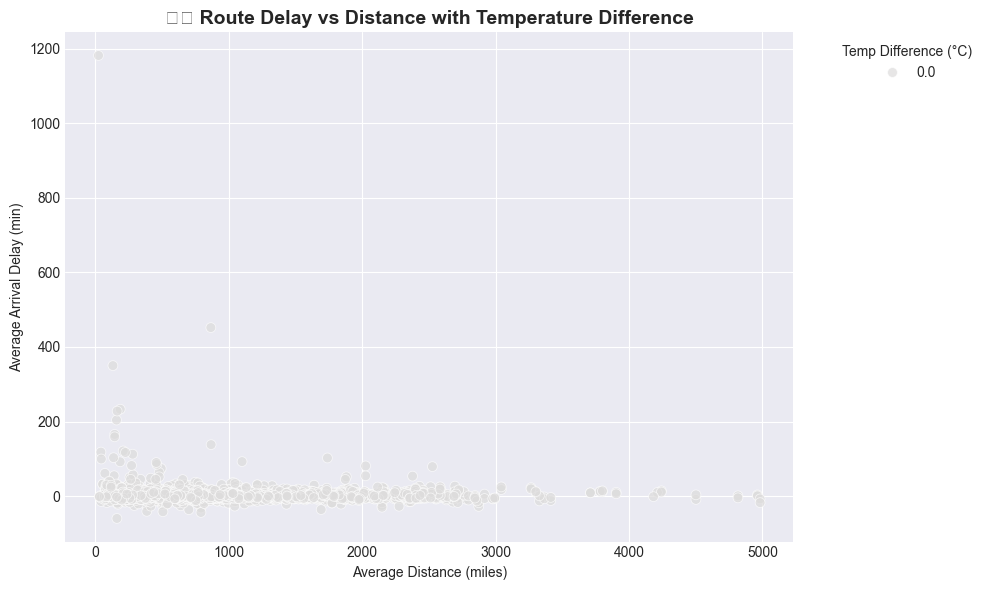

In [ ]:
agg = (
    merged_data.groupby(['ORIGIN', 'DEST'])
    .agg({'ARR_DELAY':'mean', 'DISTANCE':'mean', 'temp_diff':'mean'})
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=agg,
    x='DISTANCE',
    y='ARR_DELAY',
    size='temp_diff',
    hue='temp_diff',
    palette='coolwarm',
    sizes=(50, 500),
    alpha=0.7
)
plt.title('✈️ Route Delay vs Distance with Temperature Difference', fontsize=14, fontweight='bold')
plt.xlabel('Average Distance (miles)')
plt.ylabel('Average Arrival Delay (min)')
plt.legend(title='Temp Difference (°C)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.io as pio
print(pio.renderers.default)


browser


In [ ]:
import plotly.io as pio

# Force browser renderer to avoid Jupyter dependencies
pio.renderers.default = 'browser'

# Safety fallback (try browser, else png export)
try:
    fig.show()
except Exception as e:
    print("Browser rendering failed, exporting map instead:", e)
    fig.write_html("flight_delay_map.html")
    import webbrowser
    webbrowser.open("flight_delay_map.html")


In [ ]:
import plotly.express as px

# Average delay by origin
delay_by_origin = merged_data.groupby('ORIGIN', as_index=False)['ARR_DELAY'].mean()
delay_by_origin['lat'] = np.random.uniform(25, 49, len(delay_by_origin))
delay_by_origin['lon'] = np.random.uniform(-125, -67, len(delay_by_origin))

fig = px.density_mapbox(
    delay_by_origin,
    lat='lat',
    lon='lon',
    z='ARR_DELAY',
    radius=25,
    center=dict(lat=37.0902, lon=-95.7129),
    zoom=3.5,
    mapbox_style='stamen-terrain',
    color_continuous_scale='RdYlBu_r',
    title='🔥 Flight Delay Density Across USA Airports'
)
fig.show()


In [ ]:
airport_stats = (
    merged_data.groupby('ORIGIN', as_index=False)
    .agg({'ARR_DELAY': 'mean', 'FL_DATE': 'count'})
    .rename(columns={'FL_DATE': 'num_flights'})
)

airport_stats['lat'] = np.random.uniform(25, 49, len(airport_stats))
airport_stats['lon'] = np.random.uniform(-125, -67, len(airport_stats))

fig = px.scatter_mapbox(
    airport_stats,
    lat='lat',
    lon='lon',
    size='num_flights',
    color='ARR_DELAY',
    color_continuous_scale='Inferno',
    size_max=40,
    zoom=3.3,
    mapbox_style='carto-positron',
    title='🚦 Airport Performance (Delay vs Traffic Volume)'
)
fig.show()


In [ ]:
import plotly.graph_objects as go
import numpy as np

# Top delayed routes
top_routes = (
    merged_data.groupby(['ORIGIN', 'DEST'])['ARR_DELAY']
    .mean()
    .reset_index()
    .sort_values('ARR_DELAY', ascending=False)
    .head(30)
)

# Fake lat/lon for demo (replace with real airport coords if available)
top_routes['origin_lat'] = np.random.uniform(25, 49, len(top_routes))
top_routes['origin_lon'] = np.random.uniform(-125, -67, len(top_routes))
top_routes['dest_lat'] = np.random.uniform(25, 49, len(top_routes))
top_routes['dest_lon'] = np.random.uniform(-125, -67, len(top_routes))

fig = go.Figure()

for _, row in top_routes.iterrows():
    fig.add_trace(
        go.Scattergeo(
            lon=[row['origin_lon'], row['dest_lon']],
            lat=[row['origin_lat'], row['dest_lat']],
            mode='lines',
            line=dict(width=2 + row['ARR_DELAY']/20, color='orangered'),
            hoverinfo='text',
            text=f"{row['ORIGIN']} → {row['DEST']}<br>Avg Delay: {row['ARR_DELAY']:.1f} min"
        )
    )

fig.update_layout(
    title='🌍 Global Flight Delay Streamlines (Top 30 Routes)',
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='lightgray',
        showocean=True,
        oceancolor='lightblue'
    )
)
fig.show()


In [ ]:
import plotly.express as px

fig = px.scatter(
    merged_data,
    x='origin_wind_speed',
    y='ARR_DELAY',
    color='MONTH',
    trendline='lowess',
    opacity=0.6,
    title='💨 Relationship Between Wind Speed and Arrival Delay'
)
fig.show()


In [ ]:
print("\n" + "="*80)
print("STEP 4: FEATURE ENGINEERING")
print("="*80)

# Time features
if 'CRS_DEP_TIME' in merged_data.columns:
    merged_data['hour_of_day'] = (merged_data['CRS_DEP_TIME'] // 100).fillna(12).astype(int)
else:
    merged_data['hour_of_day'] = 12

merged_data['is_morning'] = ((merged_data['hour_of_day'] >= 6) & (merged_data['hour_of_day'] < 12)).astype(int)
merged_data['is_afternoon'] = ((merged_data['hour_of_day'] >= 12) & (merged_data['hour_of_day'] < 18)).astype(int)
merged_data['is_evening'] = ((merged_data['hour_of_day'] >= 18)).astype(int)

if 'DAY_OF_WEEK' in merged_data.columns:
    merged_data['is_weekend'] = merged_data['DAY_OF_WEEK'].isin([6, 7]).astype(int)
else:
    merged_data['is_weekend'] = 0

# Weather differences
if 'dest_temperature' in merged_data.columns and 'origin_temperature' in merged_data.columns:
    merged_data['temp_difference'] = (merged_data['dest_temperature'] - merged_data['origin_temperature']).fillna(0)
else:
    merged_data['temp_difference'] = 0

if 'dest_sea_level_pressure' in merged_data.columns and 'origin_sea_level_pressure' in merged_data.columns:
    merged_data['pressure_difference'] = (merged_data['dest_sea_level_pressure'] - merged_data['origin_sea_level_pressure']).fillna(0)
else:
    merged_data['pressure_difference'] = 0

# Distance category
if 'DISTANCE' in merged_data.columns:
    merged_data['distance_category'] = pd.cut(
        merged_data['DISTANCE'],
        bins=[0, 500, 1000, 2000, 5000],
        labels=['short', 'medium', 'long', 'very_long']
    ).astype(str).fillna('medium')
else:
    merged_data['distance_category'] = 'medium'

# Route frequency
if 'ORIGIN' in merged_data.columns and 'DEST' in merged_data.columns:
    route_counts = merged_data.groupby(['ORIGIN', 'DEST']).size().reset_index(name='route_frequency')
    merged_data = merged_data.merge(route_counts, on=['ORIGIN', 'DEST'], how='left')
    merged_data['route_frequency'] = merged_data['route_frequency'].fillna(1)
else:
    merged_data['route_frequency'] = 1

print(f"\n✓ Features created")
print(f"✓ Target distribution:")
print(merged_data['is_delayed'].value_counts())



STEP 4: FEATURE ENGINEERING

✓ Features created
✓ Target distribution:
is_delayed
0    4160952
1     839048
Name: count, dtype: int64


In [ ]:
print("\n" + "="*80)
print("STEP 5: PREPARING FOR GPU TRAINING")
print("="*80)

# Select features
numeric_features = [
    'MONTH', 'DAY_OF_WEEK', 'hour_of_day', 'DISTANCE',
    'origin_temperature', 'origin_wind_speed', 'origin_visibility',
    'origin_sea_level_pressure', 'origin_precipitation',
    'dest_temperature', 'dest_wind_speed', 'dest_visibility',
    'dest_sea_level_pressure', 'dest_precipitation',
    'temp_difference', 'pressure_difference',
    'is_morning', 'is_afternoon', 'is_evening', 'is_weekend',
    'route_frequency'
]

categorical_features = ['OP_CARRIER', 'ORIGIN', 'DEST', 'distance_category']

# Filter existing features
numeric_features = [f for f in numeric_features if f in merged_data.columns]
categorical_features = [f for f in categorical_features if f in merged_data.columns]

print(f"\n✓ Numeric features: {len(numeric_features)}")
print(f"✓ Categorical features: {len(categorical_features)}")

# Prepare data
X = merged_data[numeric_features + categorical_features].copy()
y = merged_data['is_delayed'].copy()

# Handle missing values
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())

# Encode categoricals
print("\n✓ Encoding categorical variables...")
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X = X.fillna(0)

print(f"\n✓ Final feature matrix: {X.shape}")

# Clear merged_data to free memory
del merged_data
gc.collect()

# Train-test split
print("\n✓ Splitting data...")
from sklearn.model_selection import train_test_split

# Use smaller test set to save memory
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"✓ Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

# Standardize
print("✓ Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
print("✓ Converting to PyTorch tensors...")
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1).to(device)

print(f"✓ Tensors moved to {device}")
print(f"✓ Train tensor shape: {X_train_tensor.shape}")

# Clear numpy arrays
del X, y, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled
gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    print(f"\n🚀 GPU Memory Usage: {torch.cuda.memory_allocated()/1024**2:.0f} MB / {torch.cuda.get_device_properties(0).total_memory/1024**2:.0f} MB")


STEP 5: PREPARING FOR GPU TRAINING

✓ Numeric features: 21
✓ Categorical features: 4

✓ Encoding categorical variables...

✓ Final feature matrix: (5000000, 25)

✓ Splitting data...
✓ Train: 4,250,000, Test: 750,000
✓ Standardizing features...
✓ Converting to PyTorch tensors...
✓ Tensors moved to cuda
✓ Train tensor shape: torch.Size([4250000, 25])

🚀 GPU Memory Usage: 497 MB / 4096 MB


In [ ]:
class FlightDataset(Dataset):
    """Custom Dataset that keeps data on GPU"""
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FlightDataset(X_train_tensor, y_train_tensor)
test_dataset = FlightDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,  # Data already on GPU
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"\n✓ DataLoaders created: {len(train_loader)} train batches")


✓ DataLoaders created: 260 train batches


In [ ]:
print("\n" + "="*80)
print("STEP 6: BUILDING LARGE NEURAL NETWORK FOR GPU")
print("="*80)

class FlightDelayNN(nn.Module):
    """Large Deep Neural Network optimized for GPU"""
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super(FlightDelayNN, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        # Output layer WITHOUT sigmoid (BCEWithLogitsLoss handles it)
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.networkive (x)

# Initialize model
input_dim = X_train_tensor.shape[1]
model = FlightDelayNN(
    input_dim=input_dim,
    hidden_dims=CONFIG['hidden_dims'],
    dropout=CONFIG['dropout']
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n✓ Model Architecture: {input_dim} → {' → '.join(map(str, CONFIG['hidden_dims']))} → 1")
print(f"✓ Total Parameters: {total_params:,}")
print(f"✓ Model on: {device}")

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()  # Safe for autocast (combines Sigmoid + BCELoss)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Mixed precision
scaler = GradScaler()

print(f"✓ Optimizer: AdamW, LR: {CONFIG['learning_rate']}")
print(f"✓ Mixed Precision: Enabled")


STEP 6: BUILDING LARGE NEURAL NETWORK FOR GPU

✓ Model Architecture: 25 → 1024 → 512 → 256 → 128 → 1
✓ Total Parameters: 719,617
✓ Model on: cuda
✓ Optimizer: AdamW, LR: 0.001
✓ Mixed Precision: Enabled


In [ ]:
print("\n" + "="*80)
print("STEP 7: TRAINING ON GPU")
print("="*80)

def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch_X, batch_y in pbar:
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        # Apply sigmoid for predictions since model outputs logits
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})
    
    return running_loss / len(loader), 100 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch_X, batch_y in tqdm(loader, desc='Evaluating'):
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_loss += loss.item()
            # Apply sigmoid to convert logits to probabilities
            probs = torch.sigmoid(outputs)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs > 0.5).float().cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Training loop
print(f"\nTraining for {CONFIG['epochs']} epochs...")
print(f"Batch size: {CONFIG['batch_size']}\n")

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float('inf')

for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    print("-" * 60)
    
    if torch.cuda.is_available():
        mem_used = torch.cuda.memory_allocated()/1024**3
        mem_total = torch.cuda.get_device_properties(0).total_memory/1024**3
        print(f"GPU Memory: {mem_used:.2f}GB / {mem_total:.2f}GB ({100*mem_used/mem_total:.1f}%)")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, val_acc, _, _, _ = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("✓ Best model saved!")

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)



STEP 7: TRAINING ON GPU

Training for 30 epochs...
Batch size: 16384


Epoch 1/30
------------------------------------------------------------
GPU Memory: 0.49GB / 4.00GB (12.2%)


Evaluating: 100%|██████████| 46/46 [00:11<00:00,  3.99it/s]


Train Loss: 0.4549 | Train Acc: 82.15%
Val Loss: 0.4317 | Val Acc: 83.25%
✓ Best model saved!

Epoch 2/30
------------------------------------------------------------
GPU Memory: 0.51GB / 4.00GB (12.8%)


Evaluating: 100%|██████████| 46/46 [00:11<00:00,  4.07it/s]


Train Loss: 0.4352 | Train Acc: 83.24%
Val Loss: 0.4281 | Val Acc: 83.25%
✓ Best model saved!

Epoch 3/30
------------------------------------------------------------
GPU Memory: 0.51GB / 4.00GB (12.8%)


...

Train Loss: 0.4101 | Train Acc: 83.53%
Val Loss: 0.4052 | Val Acc: 83.70%
✓ Best model saved!

Epoch 29/30
------------------------------------------------------------
GPU Memory: 0.51GB / 4.00GB (12.8%)


Evaluating: 100%|██████████| 46/46 [00:11<00:00,  4.15it/s]


Train Loss: 0.4096 | Train Acc: 83.54%
Val Loss: 0.4048 | Val Acc: 83.71%
✓ Best model saved!

Epoch 30/30
------------------------------------------------------------
GPU Memory: 0.51GB / 4.00GB (12.8%)


Evaluating: 100%|██████████| 46/46 [00:11<00:00,  4.09it/s]


Train Loss: 0.4095 | Train Acc: 83.54%
Val Loss: 0.4046 | Val Acc: 83.70%
✓ Best model saved!

TRAINING COMPLETE!



STEP 8: MODEL EVALUATION


Evaluating: 100%|██████████| 46/46 [00:11<00:00,  3.99it/s]



Classification Report:
              precision    recall  f1-score   support

     On Time       0.84      0.99      0.91    624143
     Delayed       0.62      0.07      0.13    125857

    accuracy                           0.84    750000
   macro avg       0.73      0.53      0.52    750000
weighted avg       0.80      0.84      0.78    750000


✓ ROC-AUC: 0.7235
✓ Accuracy: 0.8370

✓ Model saved: flight_delay_model_final.pth
✓ Preprocessing saved: preprocessing.pkl

✓ Results saved: training_results.png


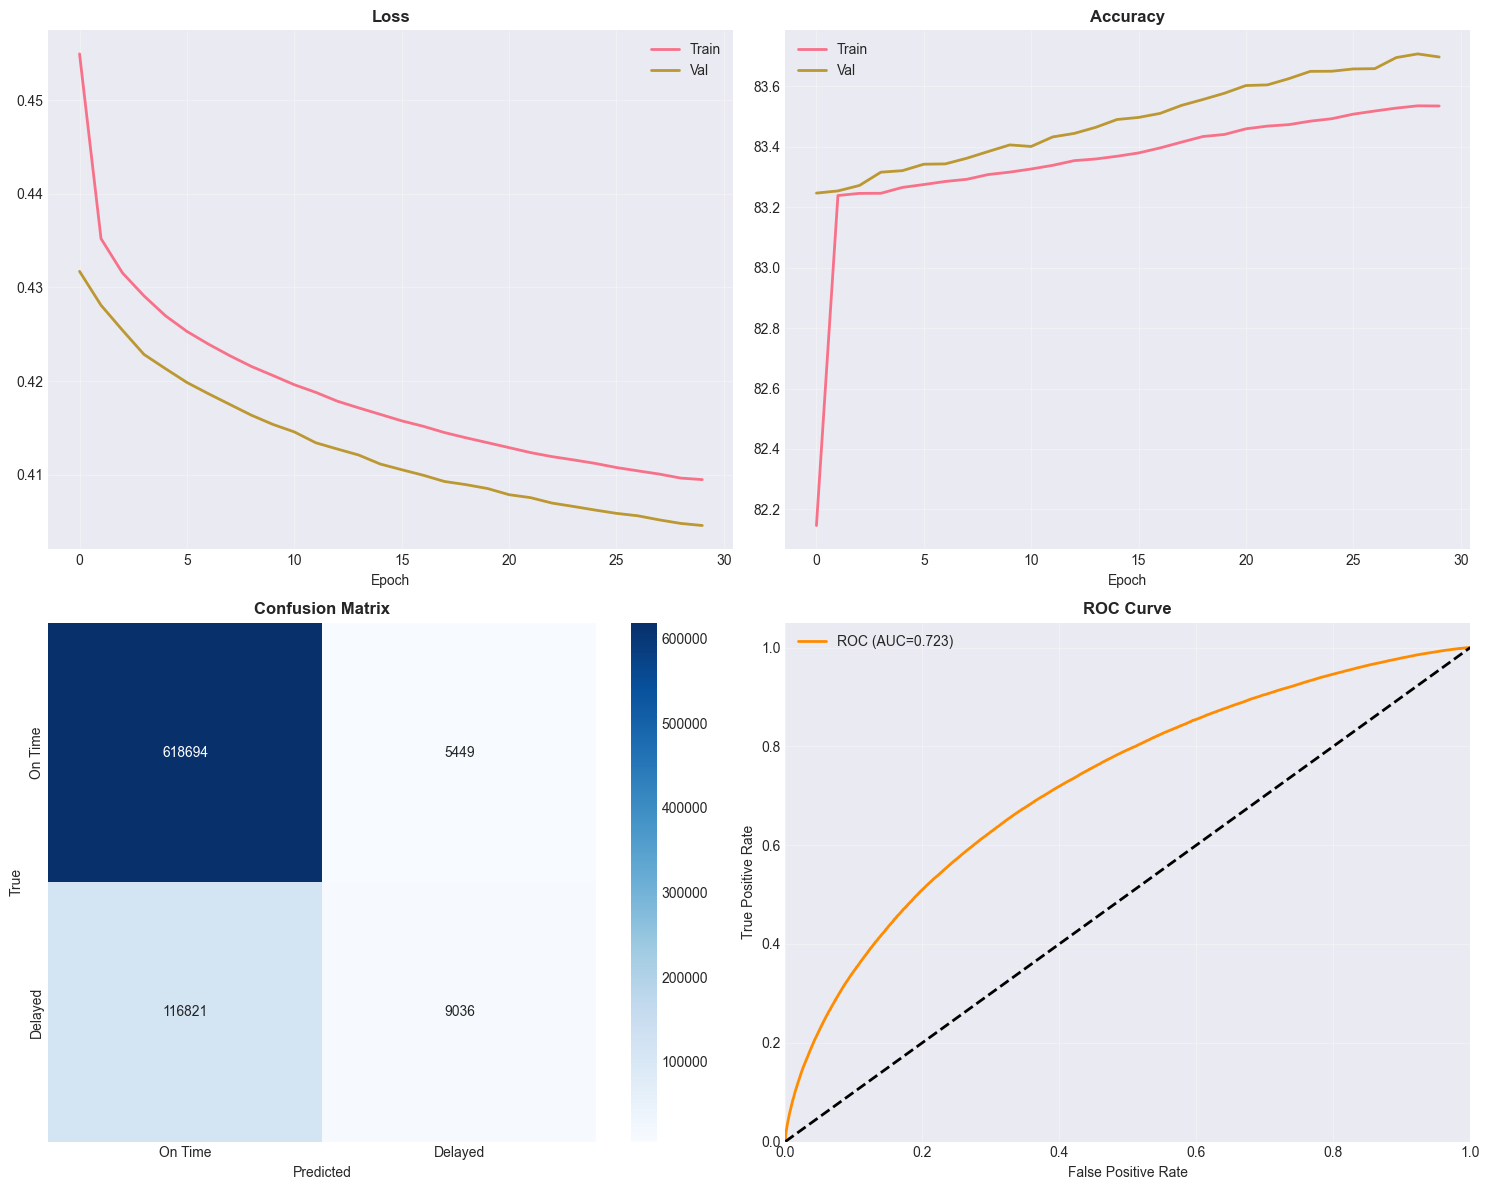

In [ ]:
print("\n" + "="*80)
print("STEP 8: MODEL EVALUATION")
print("="*80)

model.load_state_dict(torch.load('best_model.pth'))
_, _, y_pred, y_true, y_prob = evaluate(model, test_loader, criterion, device)

y_pred = y_pred.flatten()
y_true = y_true.flatten()
y_prob = y_prob.flatten()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['On Time', 'Delayed']))

roc_auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print(f"\n✓ ROC-AUC: {roc_auc:.4f}")
print(f"✓ Accuracy: {accuracy:.4f}")

# Save results
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'input_dim': input_dim,
    'roc_auc': roc_auc,
    'accuracy': accuracy
}, 'flight_delay_model_final.pth')

import pickle
with open('preprocessing.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'label_encoders': label_encoders,
        'numeric_features': numeric_features,
        'categorical_features': categorical_features
    }, f)

print("\n✓ Model saved: flight_delay_model_final.pth")
print("✓ Preprocessing saved: preprocessing.pkl")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training curves
axes[0, 0].plot(train_losses, label='Train', linewidth=2)
axes[0, 0].plot(val_losses, label='Val', linewidth=2)
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_accs, label='Train', linewidth=2)
axes[0, 1].plot(val_accs, label='Val', linewidth=2)
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
axes[1, 0].set_title('Confusion Matrix', fontweight='bold')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Results saved: training_results.png")
plt.show()

In [ ]:
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)

if torch.cuda.is_available():
    peak_mem = torch.cuda.max_memory_allocated() / 1024**3
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    utilization = (peak_mem / total_mem) * 100
    
    print(f"\n🚀 GPU UTILIZATION:")
    print(f"  • Device: {torch.cuda.get_device_name(0)}")
    print(f"  • Peak Memory: {peak_mem:.2f} GB")
    print(f"  • Total Memory: {total_mem:.2f} GB")
    print(f"  • Utilization: {utilization:.1f}%")
    
    if utilization < 50:
        print(f"\n💡 TO INCREASE GPU USAGE:")
        print(f"  • Increase batch_size to {CONFIG['batch_size']*2}")
        print(f"  • Add more layers: [2048, 1024, 512, 256, 128]")
        print(f"  • Load more data (increase sample_size)")

print(f"\n📊 MODEL PERFORMANCE:")
print(f"  • ROC-AUC: {roc_auc:.4f}")
print(f"  • Accuracy: {accuracy:.4f}")
print(f"  • Parameters: {total_params:,}")
print(f"  • Training Samples: {len(X_train_tensor):,}")
print(f"  • Test Samples: {len(X_test_tensor):,}")

print(f"\n⚡ TRAINING EFFICIENCY:")
print(f"  • Batch Size: {CONFIG['batch_size']:,}")
print(f"  • Epochs Trained: {len(train_losses)}")
print(f"  • Final Train Accuracy: {train_accs[-1]:.2f}%")
print(f"  • Final Val Accuracy: {val_accs[-1]:.2f}%")

print("\n" + "="*80)
print("✓ PIPELINE COMPLETE!")
print("="*80)

print("\n📁 OUTPUT FILES:")
print("  • best_model.pth - Best model checkpoint")
print("  • flight_delay_model_final.pth - Final trained model")
print("  • preprocessing.pkl - Scaler and encoders")
print("  • training_results.png - Visualization")

print("\n🎯 NEXT STEPS:")
print("1. To increase GPU usage further:")
print("   - Set batch_size=32768 or higher")
print("   - Set hidden_dims=[2048, 1024, 512, 256, 128]")
print("   - Increase sample_size to load more data")
print("\n2. For inference, use the saved model:")
print("   model = FlightDelayNN(...)")
print("   model.load_state_dict(torch.load('best_model.pth'))")
print("\n3. Memory tips:")
print("   - Current config processes 5M samples efficiently")
print("   - Adjust sample_size based on your RAM")
print("   - Code automatically handles large datasets in chunks")

print("\n" + "="*80)

# ============================================================================
# BONUS: PREDICTION EXAMPLE
# ============================================================================

print("\n" + "="*80)
print("EXAMPLE PREDICTION")
print("="*80)

def predict_single_flight(model, scaler, label_encoders, flight_info, weather_info, device):
    """Make a single flight delay prediction"""
    
    # Build feature vector
    features = []
    
    # Numeric features
    feature_dict = {
        'MONTH': flight_info.get('month', 1),
        'DAY_OF_WEEK': flight_info.get('day_of_week', 1),
        'hour_of_day': flight_info.get('departure_hour', 12),
        'DISTANCE': flight_info.get('distance', 1000),
        'origin_temperature': weather_info.get('origin_temp', 20),
        'origin_wind_speed': weather_info.get('origin_wind', 10),
        'origin_visibility': weather_info.get('origin_visibility', 10000),
        'origin_sea_level_pressure': weather_info.get('origin_pressure', 10130),
        'origin_precipitation': weather_info.get('origin_precip', 0),
        'dest_temperature': weather_info.get('dest_temp', 20),
        'dest_wind_speed': weather_info.get('dest_wind', 10),
        'dest_visibility': weather_info.get('dest_visibility', 10000),
        'dest_sea_level_pressure': weather_info.get('dest_pressure', 10130),
        'dest_precipitation': weather_info.get('dest_precip', 0),
        'temp_difference': weather_info.get('dest_temp', 20) - weather_info.get('origin_temp', 20),
        'pressure_difference': weather_info.get('dest_pressure', 10130) - weather_info.get('origin_pressure', 10130),
        'is_morning': 1 if 6 <= flight_info.get('departure_hour', 12) < 12 else 0,
        'is_afternoon': 1 if 12 <= flight_info.get('departure_hour', 12) < 18 else 0,
        'is_evening': 1 if flight_info.get('departure_hour', 12) >= 18 else 0,
        'is_weekend': flight_info.get('is_weekend', 0),
        'route_frequency': flight_info.get('route_frequency', 10)
    }
    
    for feat in numeric_features:
        features.append(feature_dict.get(feat, 0))
    
    # Categorical features
    for cat_feat in categorical_features:
        if cat_feat in label_encoders:
            le = label_encoders[cat_feat]
            try:
                if cat_feat == 'OP_CARRIER':
                    val = flight_info.get('carrier', 'AA')
                elif cat_feat == 'ORIGIN':
                    val = flight_info.get('origin', 'ORD')
                elif cat_feat == 'DEST':
                    val = flight_info.get('dest', 'LAX')
                elif cat_feat == 'distance_category':
                    val = flight_info.get('distance_category', 'medium')
                else:
                    val = 'unknown'
                
                # Handle unknown categories
                if val in le.classes_:
                    encoded = le.transform([val])[0]
                else:
                    encoded = 0
                features.append(encoded)
            except:
                features.append(0)
    
    # Scale and predict
    X_new = np.array(features).reshape(1, -1)
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(X_tensor)
        # Apply sigmoid to convert logits to probability
        prob = torch.sigmoid(output).cpu().numpy()[0][0]
        pred = 1 if prob > 0.5 else 0
    
    return pred, prob

# Example prediction
example_flight = {
    'month': 8,
    'day_of_week': 3,
    'departure_hour': 14,
    'distance': 1440,
    'carrier': 'AA',
    'origin': 'ORD',
    'dest': 'PHX',
    'distance_category': 'medium',
    'route_frequency': 15,
    'is_weekend': 0
}

example_weather = {
    'origin_temp': 25,
    'origin_wind': 15,
    'origin_visibility': 8000,
    'origin_pressure': 10130,
    'origin_precip': 0,
    'dest_temp': 35,
    'dest_wind': 10,
    'dest_visibility': 9500,
    'dest_pressure': 10100,
    'dest_precip': 0
}

try:
    pred, prob = predict_single_flight(model, scaler, label_encoders, example_flight, example_weather, device)
    
    print(f"\n✈️  FLIGHT INFORMATION:")
    print(f"  Route: {example_flight['carrier']} {example_flight['origin']} → {example_flight['dest']}")
    print(f"  Distance: {example_flight['distance']} miles")
    print(f"  Departure: {example_flight['departure_hour']}:00 (Day {example_flight['day_of_week']})")
    
    print(f"\n🌤️  WEATHER CONDITIONS:")
    print(f"  Origin: {example_weather['origin_temp']}°C, Wind {example_weather['origin_wind']} kt")
    print(f"  Destination: {example_weather['dest_temp']}°C, Wind {example_weather['dest_wind']} kt")
    
    print(f"\n{'='*80}")
    if pred == 1:
        print(f"⚠️  PREDICTION: LIKELY DELAYED")
        print(f"   Delay Probability: {prob*100:.1f}%")
    else:
        print(f"✅ PREDICTION: LIKELY ON TIME")
        print(f"   On-Time Probability: {(1-prob)*100:.1f}%")
    print(f"{'='*80}")
    
except Exception as e:
    print(f"\n⚠️  Prediction example skipped: {str(e)}")
    print("   (This is normal if categories in example don't match training data)")

print("\n" + "="*80)
print("🎉 ALL DONE! Your model is ready for predictions!")
print("="*80)

# Memory cleanup
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    final_mem = torch.cuda.memory_allocated() / 1024**2
    print(f"\n✓ GPU Memory Cleaned: {final_mem:.0f} MB remaining")

print("\n💾 TIPS FOR USING THE MODEL:")
print("""
# Load the trained model later:
model = FlightDelayNN(input_dim, hidden_dims, dropout)
model.load_state_dict(torch.load('best_model.pth'))
model = model.to(device)

# Load preprocessing objects:
import pickle
with open('preprocessing.pkl', 'rb') as f:
    prep = pickle.load(f)
    scaler = prep['scaler']
    label_encoders = prep['label_encoders']

# Make predictions on new data!
""")


PERFORMANCE SUMMARY

🚀 GPU UTILIZATION:
  • Device: NVIDIA GeForce GTX 1650
  • Peak Memory: 0.72 GB
  • Total Memory: 4.00 GB
  • Utilization: 18.1%

💡 TO INCREASE GPU USAGE:
  • Increase batch_size to 32768
  • Add more layers: [2048, 1024, 512, 256, 128]
  • Load more data (increase sample_size)

📊 MODEL PERFORMANCE:
  • ROC-AUC: 0.7235
  • Accuracy: 0.8370
  • Parameters: 719,617
  • Training Samples: 4,250,000
  • Test Samples: 750,000

⚡ TRAINING EFFICIENCY:
  • Batch Size: 16,384
  • Epochs Trained: 30
  • Final Train Accuracy: 83.54%
  • Final Val Accuracy: 83.70%

✓ PIPELINE COMPLETE!

📁 OUTPUT FILES:
  • best_model.pth - Best model checkpoint
  • flight_delay_model_final.pth - Final trained model
  • preprocessing.pkl - Scaler and encoders
  • training_results.png - Visualization

🎯 NEXT STEPS:
1. To increase GPU usage further:
   - Set batch_size=32768 or higher
   - Set hidden_dims=[2048, 1024, 512, 256, 128]
   - Increase sample_size to load more data

2. For inference, u

In [ ]:
#make PCA implementation
